# **Data Collection**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Prime Vector/data.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns)
df.info()

Rows: 541909
Columns: 8
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Check quantity statistics
print("Quantity:")
print(df['Quantity'].describe())

# Check unit price statistics
print("\nUnitPrice:")
print(df['UnitPrice'].describe())

Quantity:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


In [ ]:
# Check negative or zero quantities
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())

# Check zero or negative prices
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517


In [ ]:
# Check invoices starting with 'C'
cancelled = df['InvoiceNo'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled.sum())

Cancelled transactions: 9288


In [ ]:
# Remove transactions with invalid quantity or price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Check the new size
print("Rows after cleaning:", len(df))

Rows after cleaning: 530104


In [ ]:
# Calculate total sales/revenue for each transaction
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# View the result
df[['Quantity', 'UnitPrice', 'TotalSales']].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
# Count duplicate rows
df.duplicated().sum()

np.int64(5226)

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check new shape
df.shape

(524878, 9)

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check the result
df['InvoiceDate'].dtype

dtype('<M8[ns]')

# **Data Validation**

In [ ]:
print("First transaction:", df['InvoiceDate'].min())
print("Last transaction:", df['InvoiceDate'].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [ ]:
# Create Year and Month columns
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Number of transactions by year
df['Year'].value_counts().sort_index()

,count
Year,
2010,40991
2011,483887


In [ ]:
total_revenue = df['TotalSales'].sum()
total_transactions = df['InvoiceNo'].nunique()
total_products = df['StockCode'].nunique()
total_customers = df['CustomerID'].nunique()

print("Total Revenue:", total_revenue)
print("Total Transactions:", total_transactions)
print("Unique Products:", total_products)
print("Unique Customers:", total_customers)

Total Revenue: 10642110.804
Total Transactions: 19960
Unique Products: 3922
Unique Customers: 4338


In [ ]:
# Create a monthly sales dataset
monthly_sales = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
)['TotalSales'].sum()

monthly_sales

,TotalSales
InvoiceDate,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


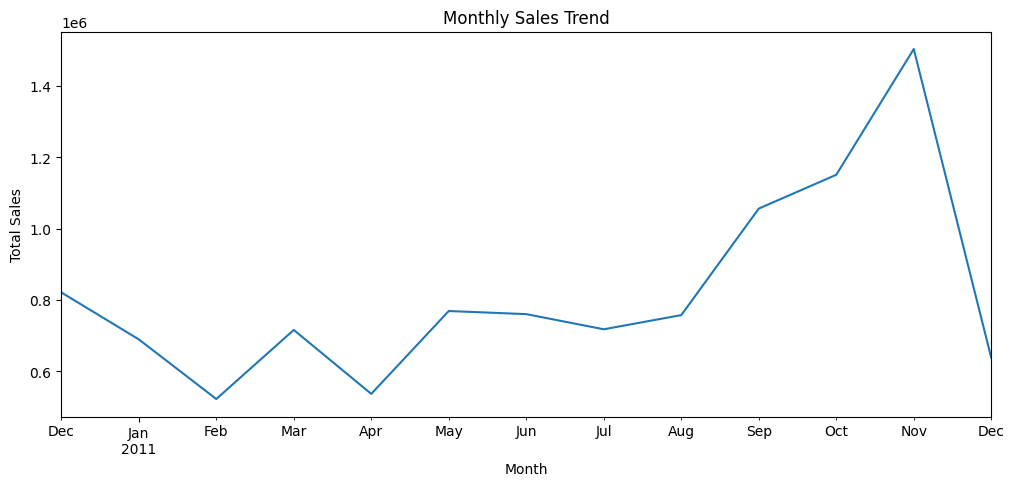

In [ ]:
import matplotlib.pyplot as plt
monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Sales Trend'
)

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
top_products = (
    df.groupby('Description')['TotalSales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,TotalSales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


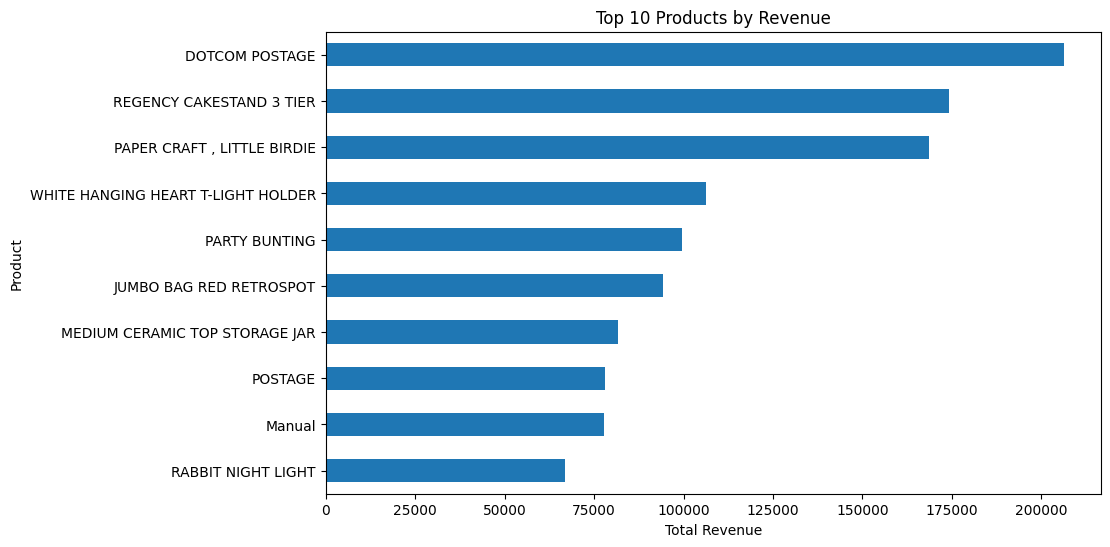

In [ ]:
top_products.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Products by Revenue'
)

plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.show()

In [ ]:
top_quantity_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_quantity_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


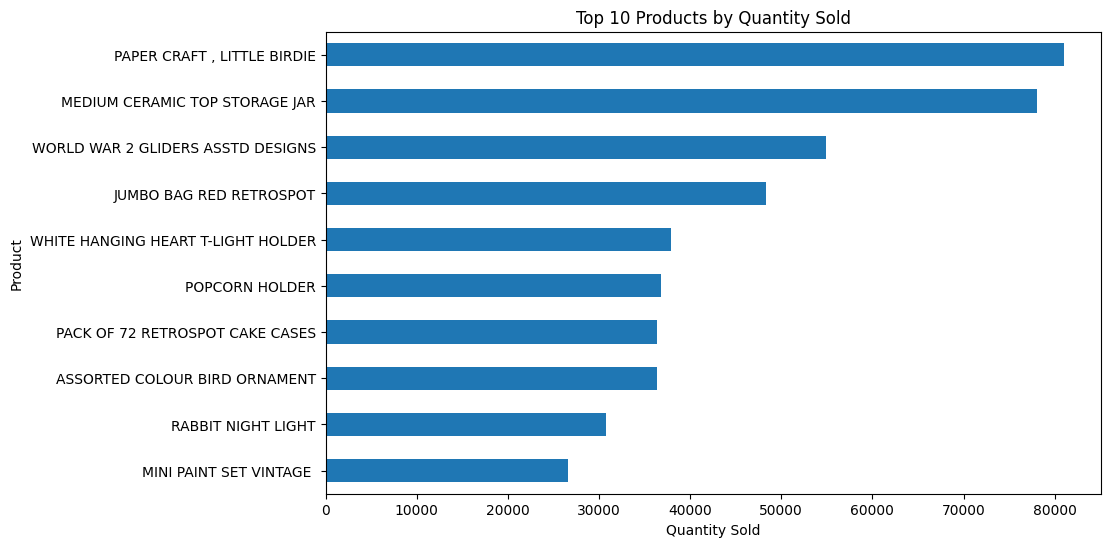

In [ ]:
top_quantity_products.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Products by Quantity Sold'
)

plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

In [ ]:
top_countries = (
    df.groupby('Country')['TotalSales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries

,TotalSales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


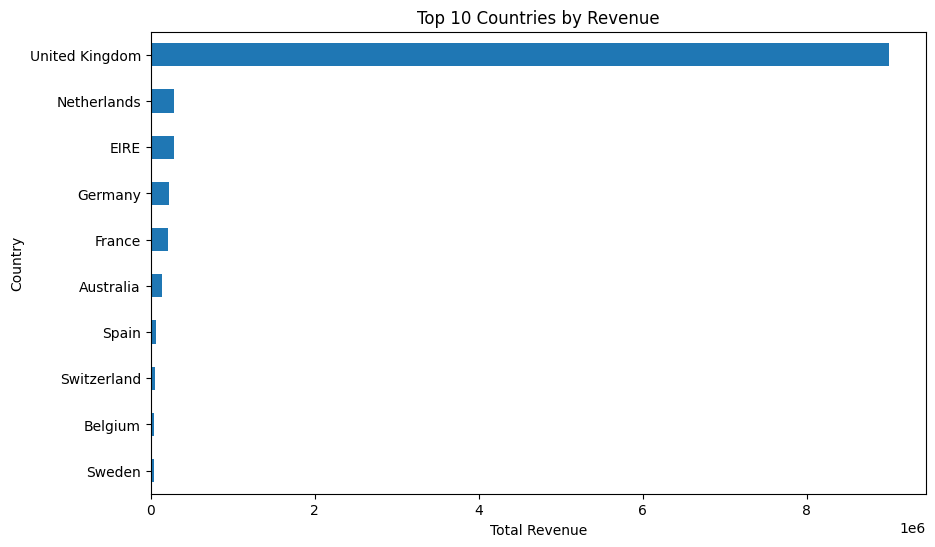

In [ ]:
top_countries.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Countries by Revenue'
)

plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()

In [ ]:
customer_df = df.dropna(subset=['CustomerID']).copy()

print("Customer dataset shape:", customer_df.shape)
print("Unique customers:", customer_df['CustomerID'].nunique())

Customer dataset shape: (392692, 11)
Unique customers: 4338


In [ ]:
customer_revenue = (
    customer_df.groupby('CustomerID')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

,TotalSales
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [ ]:
customer_orders = (
    customer_df.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


# **RFM Customer Analysis**

In [ ]:
reference_date = customer_df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [ ]:
rfm = customer_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1, 2, 3, 4]
)

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,7,4310.00,4,4,4,12
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,3,1,4,8
12350.0,310,1,334.40,1,1,2,4


In [ ]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,7,4310.00,4,4,4,12
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,3,1,4,8
12350.0,310,1,334.40,1,1,2,4
12352.0,36,8,2506.04,3,4,4,11
12353.0,204,1,89.00,1,1,1,3
12354.0,232,1,1079.40,1,1,3,5
12355.0,214,1,459.40,1,1,2,4


In [ ]:
rfm['RFM_Score'].value_counts().sort_index()

,count
RFM_Score,
3,300
4,506
5,485
6,504
7,431
8,435
9,410
10,391
11,387


In [ ]:
rfm_distribution = (
    rfm['RFM_Score']
    .value_counts()
    .sort_index()
    .to_frame('Customer_Count')
)

rfm_distribution['Percentage'] = (
    rfm_distribution['Customer_Count']
    / len(rfm)
    * 100
).round(2)

rfm_distribution

,Customer_Count,Percentage
RFM_Score,,
3,300,6.92
4,506,11.66
5,485,11.18
6,504,11.62
7,431,9.94
8,435,10.03
9,410,9.45
10,391,9.01
11,387,8.92


In [ ]:
rfm['RFM_Score'].describe()

,RFM_Score
count,4338.000000
mean,7.513831
std,2.827109
min,3.000000
25%,5.000000
50%,7.000000
75%,10.000000
max,12.000000


In [ ]:
def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Potential/Loyal'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Inactive'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,6,At Risk
12347.0,2,7,4310.00,4,4,4,12,Champions
12348.0,75,4,1797.24,2,3,4,9,Potential/Loyal
12349.0,19,1,1757.55,3,1,4,8,Potential/Loyal
12350.0,310,1,334.40,1,1,2,4,Inactive
12352.0,36,8,2506.04,3,4,4,11,Champions
12353.0,204,1,89.00,1,1,1,3,Inactive
12354.0,232,1,1079.40,1,1,3,5,At Risk
12355.0,214,1,459.40,1,1,2,4,Inactive


In [ ]:
segment_counts = rfm['Segment'].value_counts()

segment_counts

,count
Segment,
Potential/Loyal,1276
Champions,1267
At Risk,989
Inactive,806


In [ ]:
segment_percentage = (
    rfm['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
Potential/Loyal,29.41
Champions,29.21
At Risk,22.80
Inactive,18.58


# **KPI Analysis**

In [ ]:
total_revenue = df['TotalSales'].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 10642110.8


In [ ]:
total_orders = df['InvoiceNo'].nunique()

print("Total Orders:", total_orders)

Total Orders: 19960


In [ ]:
unique_customers = customer_df['CustomerID'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 4338


In [ ]:
unique_products = df['StockCode'].nunique()

print("Unique Products:", unique_products)

Unique Products: 3922


In [ ]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 533.17


In [ ]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5572420


In [ ]:
average_quantity_per_order = total_quantity / total_orders

print("Average Quantity per Order:", round(average_quantity_per_order, 2))

Average Quantity per Order: 279.18


In [ ]:
average_revenue_per_customer = total_revenue / unique_customers

print("Average Revenue per Customer:", round(average_revenue_per_customer, 2))

Average Revenue per Customer: 2453.23


In [ ]:
order_revenue = df.groupby('InvoiceNo')['TotalSales'].sum()

print("Minimum Order Revenue:", round(order_revenue.min(), 2))
print("Maximum Order Revenue:", round(order_revenue.max(), 2))
print("Mean Order Revenue:", round(order_revenue.mean(), 2))
print("Median Order Revenue:", round(order_revenue.median(), 2))
print("Standard Deviation:", round(order_revenue.std(), 2))

Minimum Order Revenue: 0.38
Maximum Order Revenue: 168469.6
Mean Order Revenue: 533.17
Median Order Revenue: 303.3
Standard Deviation: 1780.41


In [ ]:
monthly_kpi = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
).agg(
    Total_Revenue=('TotalSales', 'sum'),
    Average_Revenue=('TotalSales', 'mean'),
    Total_Orders=('InvoiceNo', 'nunique')
).reset_index()

monthly_kpi['InvoiceDate'] = monthly_kpi['InvoiceDate'].astype(str)

monthly_kpi['Revenue_Growth_%'] = (
    monthly_kpi['Total_Revenue'].pct_change() * 100
)

monthly_kpi

,InvoiceDate,Total_Revenue,Average_Revenue,Total_Orders,Revenue_Growth_%
0,2010-12,821452.730,20.039831,1559,NaN
1,2011-01,689811.610,20.252836,1086,-16.025404
2,2011-02,522545.560,19.438493,1100,-24.248077
3,2011-03,716215.260,20.176783,1454,37.062740
4,2011-04,536968.491,18.591804,1246,-25.026941
5,2011-05,769296.610,21.418732,1681,43.266620
6,2011-06,760547.010,21.294294,1533,-1.137351
7,2011-07,718076.121,18.702334,1475,-5.584256
8,2011-08,757841.380,22.117715,1361,5.537750
9,2011-09,1056435.192,21.603992,1837,39.400568


In [ ]:
monthly_kpi.round(2)

,InvoiceDate,Total_Revenue,Average_Revenue,Total_Orders,Revenue_Growth_%
0,2010-12,821452.73,20.04,1559,NaN
1,2011-01,689811.61,20.25,1086,-16.03
2,2011-02,522545.56,19.44,1100,-24.25
3,2011-03,716215.26,20.18,1454,37.06
4,2011-04,536968.49,18.59,1246,-25.03
5,2011-05,769296.61,21.42,1681,43.27
6,2011-06,760547.01,21.29,1533,-1.14
7,2011-07,718076.12,18.70,1475,-5.58
8,2011-08,757841.38,22.12,1361,5.54
9,2011-09,1056435.19,21.60,1837,39.40


# **Feature Engg & Data Transformation**

In [ ]:
daily_sales = df.groupby(
    df['InvoiceDate'].dt.date
)['TotalSales'].sum().reset_index()

daily_sales.columns = ['Date', 'DailySales']

daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

daily_sales.head()

,Date,DailySales
0,2010-12-01,58776.79
1,2010-12-02,47629.42
2,2010-12-03,46898.63
3,2010-12-05,31364.63
4,2010-12-06,54624.15


In [ ]:
print("Daily sales shape:", daily_sales.shape)
print("First date:", daily_sales['Date'].min())
print("Last date:", daily_sales['Date'].max())

Daily sales shape: (305, 2)
First date: 2010-12-01 00:00:00
Last date: 2011-12-09 00:00:00


In [ ]:
daily_sales.describe()

,Date,DailySales
count,305,305.000000
mean,2011-06-10 20:03:56.065573888,34892.166570
min,2010-12-01 00:00:00,3439.670000
25%,2011-03-10 00:00:00,22345.930000
50%,2011-06-14 00:00:00,29526.290000
75%,2011-09-12 00:00:00,45277.920000
max,2011-12-09 00:00:00,200900.980000
std,NaN,21098.282521


In [ ]:
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['Quarter'] = daily_sales['Date'].dt.quarter
daily_sales['DayOfYear'] = daily_sales['Date'].dt.dayofyear

daily_sales['IsWeekend'] = (
    daily_sales['DayOfWeek'] >= 5
).astype(int)

daily_sales.head()

,Date,DailySales,Year,Month,Day,DayOfWeek,Quarter,DayOfYear,IsWeekend
0,2010-12-01,58776.79,2010,12,1,2,4,335,0
1,2010-12-02,47629.42,2010,12,2,3,4,336,0
2,2010-12-03,46898.63,2010,12,3,4,4,337,0
3,2010-12-05,31364.63,2010,12,5,6,4,339,1
4,2010-12-06,54624.15,2010,12,6,0,4,340,0


In [ ]:
daily_sales.head(10)

,Date,DailySales,Year,Month,Day,DayOfWeek,Quarter,DayOfYear,IsWeekend
0,2010-12-01,58776.79,2010,12,1,2,4,335,0
1,2010-12-02,47629.42,2010,12,2,3,4,336,0
2,2010-12-03,46898.63,2010,12,3,4,4,337,0
3,2010-12-05,31364.63,2010,12,5,6,4,339,1
4,2010-12-06,54624.15,2010,12,6,0,4,340,0
5,2010-12-07,99553.85,2010,12,7,1,4,341,0
6,2010-12-08,45235.36,2010,12,8,2,4,342,0
7,2010-12-09,53548.19,2010,12,9,3,4,343,0
8,2010-12-10,59021.02,2010,12,10,4,4,344,0
9,2010-12-12,17125.65,2010,12,12,6,4,346,1


In [ ]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        305 non-null    datetime64[ns]
 1   DailySales  305 non-null    float64       
 2   Year        305 non-null    int32         
 3   Month       305 non-null    int32         
 4   Day         305 non-null    int32         
 5   DayOfWeek   305 non-null    int32         
 6   Quarter     305 non-null    int32         
 7   DayOfYear   305 non-null    int32         
 8   IsWeekend   305 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int32(6), int64(1)
memory usage: 14.4 KB


In [ ]:
daily_sales['Lag_1'] = daily_sales['DailySales'].shift(1)
daily_sales['Lag_7'] = daily_sales['DailySales'].shift(7)
daily_sales['Lag_30'] = daily_sales['DailySales'].shift(30)

daily_sales.head(10)

,Date,DailySales,Year,Month,Day,DayOfWeek,Quarter,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30
0,2010-12-01,58776.79,2010,12,1,2,4,335,0,NaN,NaN,NaN
1,2010-12-02,47629.42,2010,12,2,3,4,336,0,58776.79,NaN,NaN
2,2010-12-03,46898.63,2010,12,3,4,4,337,0,47629.42,NaN,NaN
3,2010-12-05,31364.63,2010,12,5,6,4,339,1,46898.63,NaN,NaN
4,2010-12-06,54624.15,2010,12,6,0,4,340,0,31364.63,NaN,NaN
5,2010-12-07,99553.85,2010,12,7,1,4,341,0,54624.15,NaN,NaN
6,2010-12-08,45235.36,2010,12,8,2,4,342,0,99553.85,NaN,NaN
7,2010-12-09,53548.19,2010,12,9,3,4,343,0,45235.36,58776.79,NaN
8,2010-12-10,59021.02,2010,12,10,4,4,344,0,53548.19,47629.42,NaN
9,2010-12-12,17125.65,2010,12,12,6,4,346,1,59021.02,46898.63,NaN


In [ ]:
daily_sales['Rolling_Mean_7'] = (
    daily_sales['DailySales']
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_sales['Rolling_Mean_30'] = (
    daily_sales['DailySales']
    .shift(1)
    .rolling(window=30)
    .mean()
)

daily_sales.head(10)

,Date,DailySales,Year,Month,Day,DayOfWeek,Quarter,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2010-12-01,58776.79,2010,12,1,2,4,335,0,NaN,NaN,NaN,NaN,NaN
1,2010-12-02,47629.42,2010,12,2,3,4,336,0,58776.79,NaN,NaN,NaN,NaN
2,2010-12-03,46898.63,2010,12,3,4,4,337,0,47629.42,NaN,NaN,NaN,NaN
3,2010-12-05,31364.63,2010,12,5,6,4,339,1,46898.63,NaN,NaN,NaN,NaN
4,2010-12-06,54624.15,2010,12,6,0,4,340,0,31364.63,NaN,NaN,NaN,NaN
5,2010-12-07,99553.85,2010,12,7,1,4,341,0,54624.15,NaN,NaN,NaN,NaN
6,2010-12-08,45235.36,2010,12,8,2,4,342,0,99553.85,NaN,NaN,NaN,NaN
7,2010-12-09,53548.19,2010,12,9,3,4,343,0,45235.36,58776.79,NaN,54868.975714,NaN
8,2010-12-10,59021.02,2010,12,10,4,4,344,0,53548.19,47629.42,NaN,54122.032857,NaN
9,2010-12-12,17125.65,2010,12,12,6,4,346,1,59021.02,46898.63,NaN,55749.404286,NaN


In [ ]:
daily_sales.isnull().sum()

,0
Date,0
DailySales,0
Year,0
Month,0
Day,0
DayOfWeek,0
Quarter,0
DayOfYear,0
IsWeekend,0
Lag_1,1


In [ ]:
daily_sales.shape

(305, 14)

In [ ]:
ml_data = daily_sales.dropna().copy()

print("Original daily dataset:", daily_sales.shape)
print("Final ML dataset:", ml_data.shape)
print("Missing values:")
print(ml_data.isnull().sum())

Original daily dataset: (305, 14)
Final ML dataset: (275, 14)
Missing values:
Date               0
DailySales         0
Year               0
Month              0
Day                0
DayOfWeek          0
Quarter            0
DayOfYear          0
IsWeekend          0
Lag_1              0
Lag_7              0
Lag_30             0
Rolling_Mean_7     0
Rolling_Mean_30    0
dtype: int64


In [ ]:
ml_data.tail()

,Date,DailySales,Year,Month,Day,DayOfWeek,Quarter,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
300,2011-12-05,88620.84,2011,12,5,0,4,339,0,24477.47,20279.37,57327.45,49096.867143,56507.227000
301,2011-12-06,56558.83,2011,12,6,1,4,340,0,88620.84,56965.73,29091.90,58859.934286,57550.340000
302,2011-12-07,75315.55,2011,12,7,2,4,341,0,56558.83,72384.82,45690.08,58801.805714,58465.904333
303,2011-12-08,82371.55,2011,12,8,3,4,342,0,75315.55,60025.57,63425.47,59220.481429,59453.420000
304,2011-12-09,200900.98,2011,12,9,4,4,343,0,82371.55,52068.63,62594.59,62412.764286,60084.956000


# **Sales Forecast**

In [ ]:
# Features and target

X = ml_data.drop(columns=['Date', 'DailySales'])
y = ml_data['DailySales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (275, 12)
Target shape: (275,)

Feature columns:
['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Mean_30']


In [ ]:
# Chronological train-test split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(ml_data.iloc[:split_index]['Date'].min(), "to",
      ml_data.iloc[:split_index]['Date'].max())

print("\nTesting period:")
print(ml_data.iloc[split_index:]['Date'].min(), "to",
      ml_data.iloc[split_index:]['Date'].max())

Training data: (220, 12)
Testing data: (55, 12)

Training period:
2011-01-16 00:00:00 to 2011-10-06 00:00:00

Testing period:
2011-10-07 00:00:00 to 2011-12-09 00:00:00


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict sales for the test period
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression trained successfully!")
print("Number of predictions:", len(y_pred_lr))

Linear Regression trained successfully!
Number of predictions: 55


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))

Linear Regression Performance
--------------------------------
MAE : 12761.12
RMSE: 23046.29
R²  : 0.2929


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest trained successfully!
Number of predictions: 55


In [ ]:

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Performance
-------------------------
MAE : 13443.29
RMSE: 24794.86
R²  : 0.1815


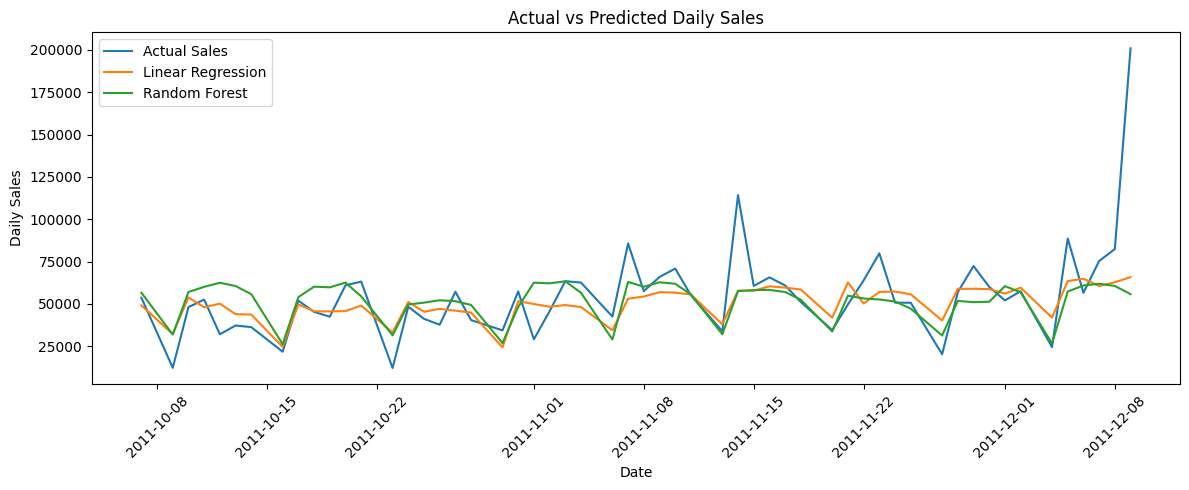

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    ml_data.iloc[split_index:]['Date'],
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    ml_data.iloc[split_index:]['Date'],
    y_pred_lr,
    label='Linear Regression'
)

plt.plot(
    ml_data.iloc[split_index:]['Date'],
    y_pred_rf,
    label='Random Forest'
)

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Actual vs Predicted Daily Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Trying again forecasting**

In [ ]:
# Create a complete calendar-based daily sales dataset

daily_calendar = (
    df.set_index('InvoiceDate')['TotalSales']
    .resample('D')
    .sum()
    .reset_index()
)

daily_calendar.columns = ['Date', 'DailySales']

print("Shape:", daily_calendar.shape)
print("\nFirst 10 rows:")
print(daily_calendar.head(10))

print("\nLast 10 rows:")
print(daily_calendar.tail(10))

Shape: (374, 2)

First 10 rows:
        Date  DailySales
0 2010-12-01    58776.79
1 2010-12-02    47629.42
2 2010-12-03    46898.63
3 2010-12-04        0.00
4 2010-12-05    31364.63
5 2010-12-06    54624.15
6 2010-12-07    99553.85
7 2010-12-08    45235.36
8 2010-12-09    53548.19
9 2010-12-10    59021.02

Last 10 rows:
          Date  DailySales
364 2011-11-30    60025.57
365 2011-12-01    52068.63
366 2011-12-02    57476.48
367 2011-12-03        0.00
368 2011-12-04    24477.47
369 2011-12-05    88620.84
370 2011-12-06    56558.83
371 2011-12-07    75315.55
372 2011-12-08    82371.55
373 2011-12-09   200900.98


In [ ]:
# Create time-based features

daily_calendar['Year'] = daily_calendar['Date'].dt.year
daily_calendar['Month'] = daily_calendar['Date'].dt.month
daily_calendar['Day'] = daily_calendar['Date'].dt.day
daily_calendar['DayOfWeek'] = daily_calendar['Date'].dt.dayofweek
daily_calendar['Quarter'] = daily_calendar['Date'].dt.quarter
daily_calendar['DayOfYear'] = daily_calendar['Date'].dt.dayofyear

daily_calendar['IsWeekend'] = (
    daily_calendar['DayOfWeek'] >= 5
).astype(int)

print("Shape:", daily_calendar.shape)
print("\nColumns:")
print(daily_calendar.columns.tolist())

Shape: (374, 9)

Columns:
['Date', 'DailySales', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend']


In [ ]:
# Create calendar-based lag features

daily_calendar['Lag_1'] = daily_calendar['DailySales'].shift(1)
daily_calendar['Lag_7'] = daily_calendar['DailySales'].shift(7)
daily_calendar['Lag_30'] = daily_calendar['DailySales'].shift(30)

print(daily_calendar[['Date', 'DailySales', 'Lag_1', 'Lag_7', 'Lag_30']].head(35))

         Date  DailySales     Lag_1     Lag_7    Lag_30
0  2010-12-01    58776.79       NaN       NaN       NaN
1  2010-12-02    47629.42  58776.79       NaN       NaN
2  2010-12-03    46898.63  47629.42       NaN       NaN
3  2010-12-04        0.00  46898.63       NaN       NaN
4  2010-12-05    31364.63      0.00       NaN       NaN
5  2010-12-06    54624.15  31364.63       NaN       NaN
6  2010-12-07    99553.85  54624.15       NaN       NaN
7  2010-12-08    45235.36  99553.85  58776.79       NaN
8  2010-12-09    53548.19  45235.36  47629.42       NaN
9  2010-12-10    59021.02  53548.19  46898.63       NaN
10 2010-12-11        0.00  59021.02      0.00       NaN
11 2010-12-12    17125.65      0.00  31364.63       NaN
12 2010-12-13    37942.37  17125.65  54624.15       NaN
13 2010-12-14    45167.56  37942.37  99553.85       NaN
14 2010-12-15    30384.37  45167.56  45235.36       NaN
15 2010-12-16    49114.14  30384.37  53548.19       NaN
16 2010-12-17    45338.13  49114.14  59021.02   

In [ ]:
# Create rolling average features without target leakage

daily_calendar['Rolling_Mean_7'] = (
    daily_calendar['DailySales']
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_calendar['Rolling_Mean_30'] = (
    daily_calendar['DailySales']
    .shift(1)
    .rolling(window=30)
    .mean()
)

print(
    daily_calendar[
        ['Date', 'DailySales', 'Rolling_Mean_7', 'Rolling_Mean_30']
    ].head(35)
)

         Date  DailySales  Rolling_Mean_7  Rolling_Mean_30
0  2010-12-01    58776.79             NaN              NaN
1  2010-12-02    47629.42             NaN              NaN
2  2010-12-03    46898.63             NaN              NaN
3  2010-12-04        0.00             NaN              NaN
4  2010-12-05    31364.63             NaN              NaN
5  2010-12-06    54624.15             NaN              NaN
6  2010-12-07    99553.85             NaN              NaN
7  2010-12-08    45235.36    48406.781429              NaN
8  2010-12-09    53548.19    46472.291429              NaN
9  2010-12-10    59021.02    47317.830000              NaN
10 2010-12-11        0.00    49049.600000              NaN
11 2010-12-12    17125.65    49049.600000              NaN
12 2010-12-13    37942.37    47015.460000              NaN
13 2010-12-14    45167.56    44632.348571              NaN
14 2010-12-15    30384.37    36862.878571              NaN
15 2010-12-16    49114.14    34741.308571              N

In [ ]:
# Check missing values

print("Missing values before cleaning:")
print(daily_calendar.isnull().sum())

# Remove rows where lag/rolling features are unavailable
calendar_ml_data = daily_calendar.dropna().copy()

print("\nOriginal dataset shape:", daily_calendar.shape)
print("Final ML dataset shape:", calendar_ml_data.shape)

print("\nMissing values after cleaning:")
print(calendar_ml_data.isnull().sum())

Missing values before cleaning:
Date                0
DailySales          0
Year                0
Month               0
Day                 0
DayOfWeek           0
Quarter             0
DayOfYear           0
IsWeekend           0
Lag_1               1
Lag_7               7
Lag_30             30
Rolling_Mean_7      7
Rolling_Mean_30    30
dtype: int64

Original dataset shape: (374, 14)
Final ML dataset shape: (344, 14)

Missing values after cleaning:
Date               0
DailySales         0
Year               0
Month              0
Day                0
DayOfWeek          0
Quarter            0
DayOfYear          0
IsWeekend          0
Lag_1              0
Lag_7              0
Lag_30             0
Rolling_Mean_7     0
Rolling_Mean_30    0
dtype: int64


In [ ]:
# Define features and target for the improved forecasting dataset

X = calendar_ml_data.drop(columns=['Date', 'DailySales'])
y = calendar_ml_data['DailySales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (344, 12)
Target shape: (344,)

Feature columns:
['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Mean_30']


In [ ]:
# Chronological train-test split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(
    calendar_ml_data.iloc[:split_index]['Date'].min(),
    "to",
    calendar_ml_data.iloc[:split_index]['Date'].max()
)

print("\nTesting period:")
print(
    calendar_ml_data.iloc[split_index:]['Date'].min(),
    "to",
    calendar_ml_data.iloc[split_index:]['Date'].max()
)

Training data: (275, 12)
Testing data: (69, 12)

Training period:
2010-12-31 00:00:00 to 2011-10-01 00:00:00

Testing period:
2011-10-02 00:00:00 to 2011-12-09 00:00:00


In [ ]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict test-period sales
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression trained successfully!")
print("Number of predictions:", len(y_pred_lr))

Linear Regression trained successfully!
Number of predictions: 69


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict test-period sales
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest trained successfully!
Number of predictions: 69


In [ ]:
# Linear Regression metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Display results
print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))

print("\nRandom Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Linear Regression Performance
-----------------------------
MAE : 25273.72
RMSE: 34520.07
R²  : -0.2196

Random Forest Performance
-------------------------
MAE : 13117.32
RMSE: 23491.33
R²  : 0.4352


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Predict test-period sales
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting trained successfully!")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting trained successfully!
Number of predictions: 69


In [ ]:
# Evaluate Gradient Boosting

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R²  :", round(r2_gb, 4))

Gradient Boosting Performance
-----------------------------
MAE : 14139.41
RMSE: 24857.35
R²  : 0.3676


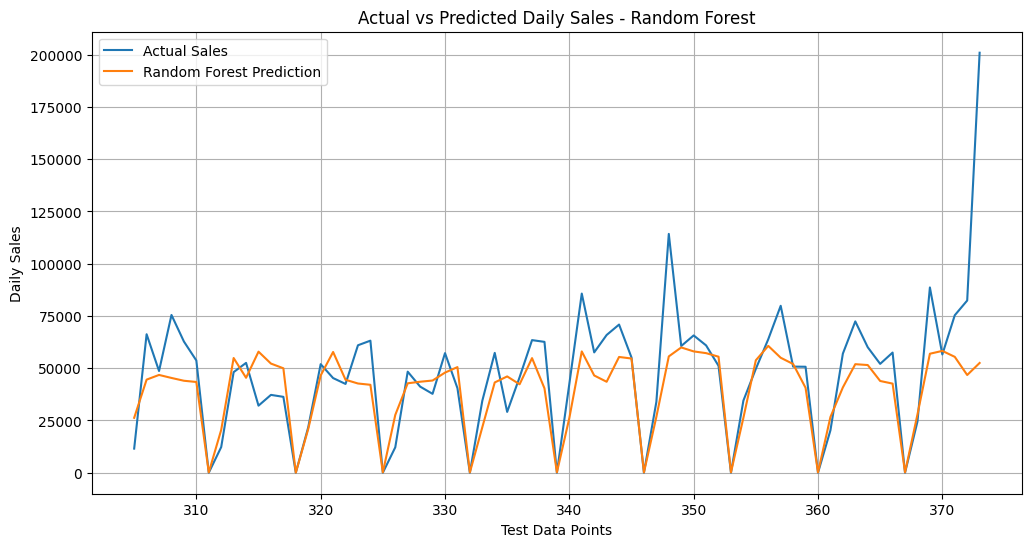

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    y_test.index,
    y_pred_rf,
    label='Random Forest Prediction'
)

plt.title('Actual vs Predicted Daily Sales - Random Forest')
plt.xlabel('Test Data Points')
plt.ylabel('Daily Sales')
plt.legend()
plt.grid(True)

plt.show()

Lag_7              0.241206
DayOfWeek          0.234620
IsWeekend          0.103553
Rolling_Mean_30    0.094148
DayOfYear          0.086921
Rolling_Mean_7     0.086199
Lag_1              0.050596
Day                0.049038
Lag_30             0.037937
Month              0.011330
Quarter            0.004134
Year               0.000317
dtype: float64


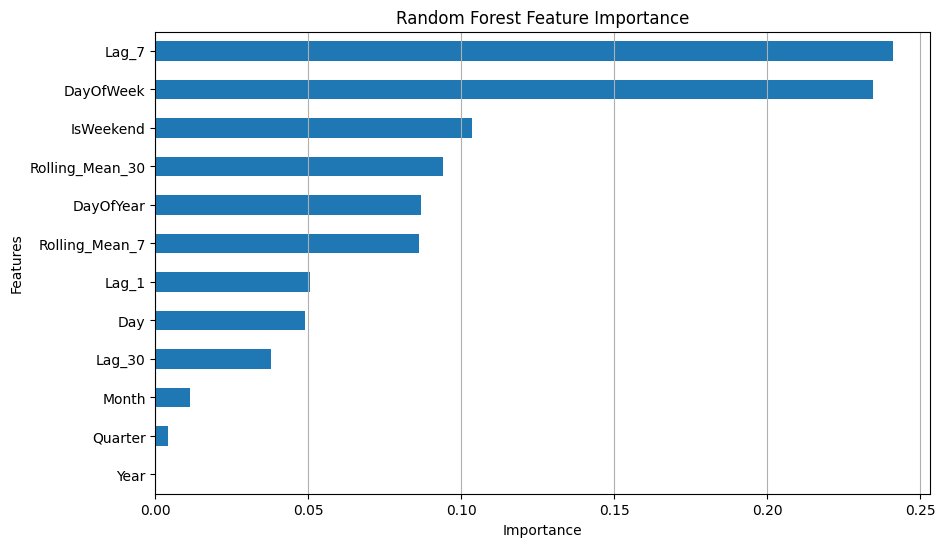

In [ ]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x')

plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest
rf_tune = RandomForestRegressor(
    random_state=42
)

# Parameters to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(round(-grid_search.best_score_, 2))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation MAE:
8530.89


In [ ]:
# Get the optimized Random Forest model

tuned_rf = grid_search.best_estimator_

# Predict on the untouched test set
y_pred_tuned_rf = tuned_rf.predict(X_test)

print("Tuned Random Forest predictions:", len(y_pred_tuned_rf))

Tuned Random Forest predictions: 69


In [ ]:

mae_tuned = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
r2_tuned = r2_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE :", round(mae_tuned, 2))
print("RMSE:", round(rmse_tuned, 2))
print("R²  :", round(r2_tuned, 4))

Tuned Random Forest Performance
--------------------------------
MAE : 13283.47
RMSE: 23682.31
R²  : 0.426


In [ ]:
# Simple 7-day lag baseline
baseline_pred = X_test['Lag_7']

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_baseline = r2_score(y_test, baseline_pred)

print("7-Day Lag Baseline Performance")
print("------------------------------")
print("MAE :", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("R²  :", round(r2_baseline, 4))



7-Day Lag Baseline Performance
------------------------------
MAE : 14371.29
RMSE: 24509.95
R²  : 0.3852


In [ ]:
# Start with the complete historical daily data
forecast_data = daily_calendar[['Date', 'DailySales']].copy()

# Number of future days
forecast_days = 7

future_predictions = []

for i in range(forecast_days):

    # Next date
    next_date = forecast_data['Date'].max() + pd.Timedelta(days=1)

    # Calendar features
    year = next_date.year
    month = next_date.month
    day = next_date.day
    day_of_week = next_date.dayofweek
    quarter = next_date.quarter
    day_of_year = next_date.dayofyear
    is_weekend = int(day_of_week >= 5)

    # Historical/predicted lag values
    lag_1 = forecast_data['DailySales'].iloc[-1]
    lag_7 = forecast_data['DailySales'].iloc[-7]
    lag_30 = forecast_data['DailySales'].iloc[-30]

    # Rolling averages using previous values only
    rolling_mean_7 = forecast_data['DailySales'].iloc[-7:].mean()
    rolling_mean_30 = forecast_data['DailySales'].iloc[-30:].mean()

    # Create feature row
    future_features = pd.DataFrame([{
        'Year': year,
        'Month': month,
        'Day': day,
        'DayOfWeek': day_of_week,
        'Quarter': quarter,
        'DayOfYear': day_of_year,
        'IsWeekend': is_weekend,
        'Lag_1': lag_1,
        'Lag_7': lag_7,
        'Lag_30': lag_30,
        'Rolling_Mean_7': rolling_mean_7,
        'Rolling_Mean_30': rolling_mean_30
    }])

    # Predict sales
    prediction = rf_model.predict(future_features)[0]

    # Avoid negative sales predictions
    prediction = max(0, prediction)

    # Store prediction
    future_predictions.append({
        'Date': next_date,
        'PredictedSales': prediction
    })

    # Add prediction to historical data
    # This allows the next future day to use it as a lag
    new_row = pd.DataFrame([{
        'Date': next_date,
        'DailySales': prediction
    }])

    forecast_data = pd.concat(
        [forecast_data, new_row],
        ignore_index=True
    )

# Convert predictions to DataFrame
forecast_df = pd.DataFrame(future_predictions)

print("Next 7 Days Sales Forecast")
print("--------------------------")
print(forecast_df)


Next 7 Days Sales Forecast
--------------------------
        Date  PredictedSales
0 2011-12-10      173.980650
1 2011-12-11    27580.614165
2 2011-12-12    54982.101560
3 2011-12-13    59659.917500
4 2011-12-14    56593.513365
5 2011-12-15    56138.118265
6 2011-12-16    54085.978570


In [ ]:
# Check recent historical sales and the forecast together

recent_history = daily_calendar[
    daily_calendar['Date'] >= daily_calendar['Date'].max() - pd.Timedelta(days=14)
][['Date', 'DailySales']]

print("Recent Historical Sales")
print("-----------------------")
print(recent_history)

print("\n7-Day Forecast")
print("--------------")
print(forecast_df)

Recent Historical Sales
-----------------------
          Date  DailySales
359 2011-11-25    50690.40
360 2011-11-26        0.00
361 2011-11-27    20279.37
362 2011-11-28    56965.73
363 2011-11-29    72384.82
364 2011-11-30    60025.57
365 2011-12-01    52068.63
366 2011-12-02    57476.48
367 2011-12-03        0.00
368 2011-12-04    24477.47
369 2011-12-05    88620.84
370 2011-12-06    56558.83
371 2011-12-07    75315.55
372 2011-12-08    82371.55
373 2011-12-09   200900.98

7-Day Forecast
--------------
        Date  PredictedSales
0 2011-12-10      173.980650
1 2011-12-11    27580.614165
2 2011-12-12    54982.101560
3 2011-12-13    59659.917500
4 2011-12-14    56593.513365
5 2011-12-15    56138.118265
6 2011-12-16    54085.978570


In [ ]:
next_date = pd.Timestamp('2011-12-10')

lag_1 = daily_calendar['DailySales'].iloc[-1]
lag_7 = daily_calendar['DailySales'].iloc[-7]
lag_30 = daily_calendar['DailySales'].iloc[-30]

rolling_mean_7 = daily_calendar['DailySales'].iloc[-7:].mean()
rolling_mean_30 = daily_calendar['DailySales'].iloc[-30:].mean()

print("Dec 10 Forecast Features")
print("------------------------")
print("Day of Week:", next_date.dayofweek)
print("Is Weekend:", int(next_date.dayofweek >= 5))
print("Lag 1:", lag_1)
print("Lag 7:", lag_7)
print("Lag 30:", lag_30)
print("Rolling Mean 7:", rolling_mean_7)
print("Rolling Mean 30:", rolling_mean_30)

Dec 10 Forecast Features
------------------------
Day of Week: 5
Is Weekend: 1
Lag 1: 200900.97999999998
Lag 7: 0.0
Lag 30: 70868.0
Rolling Mean 7: 75463.60285714285
Rolling Mean 30: 56306.63933333334


In [ ]:
saturday_sales = daily_calendar[
    daily_calendar['Date'].dt.dayofweek == 5
][['Date', 'DailySales']]

print(saturday_sales.to_string(index=False))

      Date  DailySales
2010-12-04         0.0
2010-12-11         0.0
2010-12-18         0.0
2010-12-25         0.0
2011-01-01         0.0
2011-01-08         0.0
2011-01-15         0.0
2011-01-22         0.0
2011-01-29         0.0
2011-02-05         0.0
2011-02-12         0.0
2011-02-19         0.0
2011-02-26         0.0
2011-03-05         0.0
2011-03-12         0.0
2011-03-19         0.0
2011-03-26         0.0
2011-04-02         0.0
2011-04-09         0.0
2011-04-16         0.0
2011-04-23         0.0
2011-04-30         0.0
2011-05-07         0.0
2011-05-14         0.0
2011-05-21         0.0
2011-05-28         0.0
2011-06-04         0.0
2011-06-11         0.0
2011-06-18         0.0
2011-06-25         0.0
2011-07-02         0.0
2011-07-09         0.0
2011-07-16         0.0
2011-07-23         0.0
2011-07-30         0.0
2011-08-06         0.0
2011-08-13         0.0
2011-08-20         0.0
2011-08-27         0.0
2011-09-03         0.0
2011-09-10         0.0
2011-09-17         0.0
2011-09-24 

In [ ]:
total_forecast_sales = forecast_df['PredictedSales'].sum()

print("7-Day Forecast Summary")
print("----------------------")
print("Total Predicted Sales:", round(total_forecast_sales, 2))
print("Average Predicted Daily Sales:", round(forecast_df['PredictedSales'].mean(), 2))
print("Highest Predicted Sales:", round(forecast_df['PredictedSales'].max(), 2))
print("Lowest Predicted Sales:", round(forecast_df['PredictedSales'].min(), 2))

7-Day Forecast Summary
----------------------
Total Predicted Sales: 309214.22
Average Predicted Daily Sales: 44173.46
Highest Predicted Sales: 59659.92
Lowest Predicted Sales: 173.98


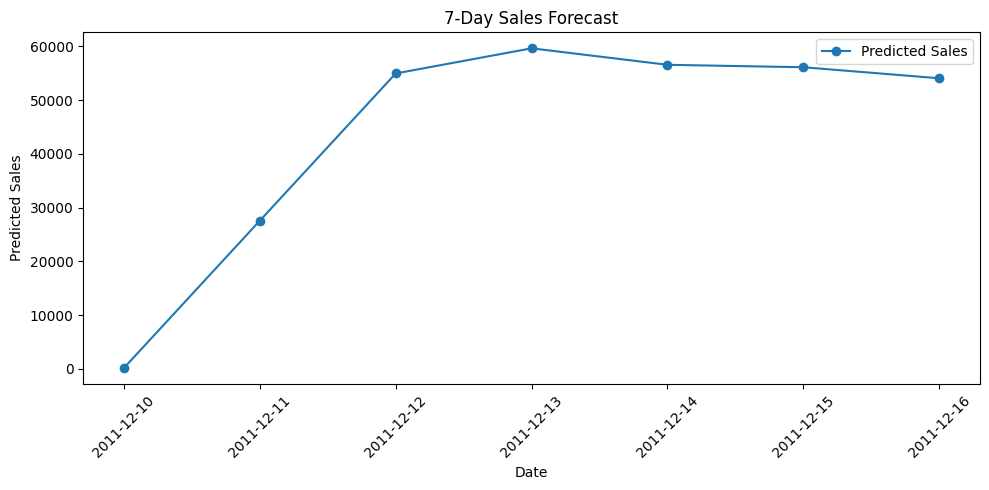

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    forecast_df['Date'],
    forecast_df['PredictedSales'],
    marker='o',
    label='Predicted Sales'
)

plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.title('7-Day Sales Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

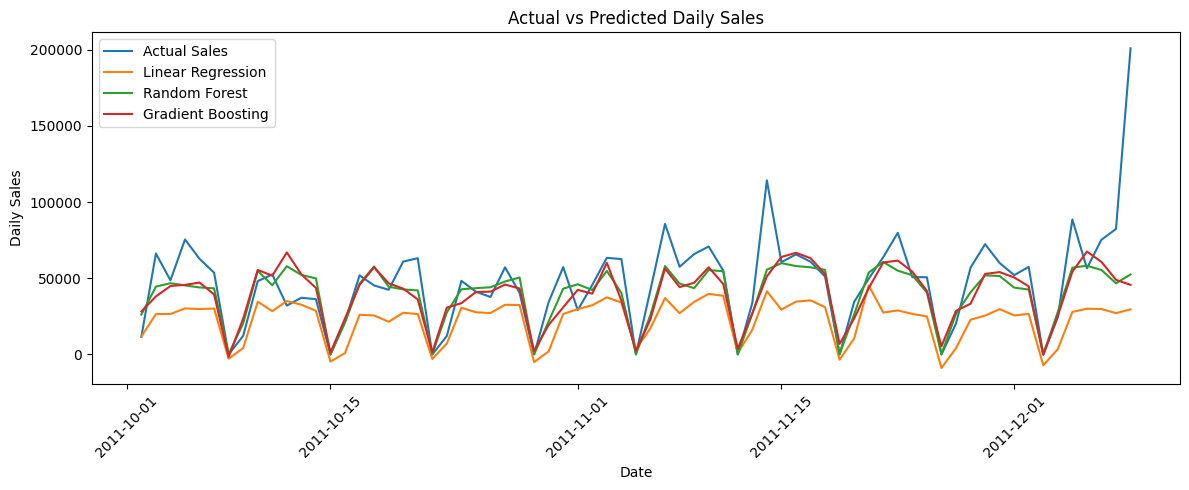

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_calendar['Date'].iloc[-69:],
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    daily_calendar['Date'].iloc[-69:],
    y_pred_lr,
    label='Linear Regression'
)

plt.plot(
    daily_calendar['Date'].iloc[-69:],
    y_pred_rf,
    label='Random Forest'
)

plt.plot(
    daily_calendar['Date'].iloc[-69:],
    y_pred_gb,
    label='Gradient Boosting'
)

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Actual vs Predicted Daily Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

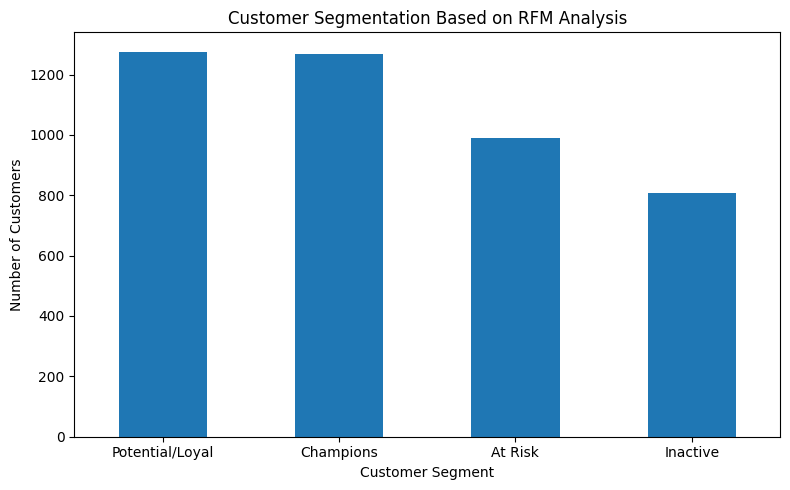

In [ ]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))

segment_counts.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segmentation Based on RFM Analysis')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()